# Cloud Kitchen Demand Forecasting

## Problem Statement

Cloud kitchens face challenges in predicting food demand accurately. 

Overproduction leads to food waste, while underproduction affects customer satisfaction. 

This project aims to build a machine learning model to forecast demand and optimize operations.

## Dataset Description

The dataset contains historical sales data including:
- Date of transaction
- Store and item identifiers
- Sales quantity
- Price and promotional information

This data is used to analyze patterns and predict future demand.

## Step 1: Data Loading

In [34]:
import pandas as pd

df = pd.read_csv("../data/retail_sales.csv")

df.head()

,date,store_id,item_id,sales,price,promo,weekday,month
0,1/1/2019,store_1,item_1,41,21.30,0,1,1
1,1/2/2019,store_1,item_1,53,21.30,0,2,1
2,1/3/2019,store_1,item_1,39,21.30,0,3,1
3,1/4/2019,store_1,item_1,35,21.30,0,4,1
4,1/5/2019,store_1,item_1,51,17.04,1,5,1


## Step 2: Exploratory Data Analysis (EDA)

EDA was performed to understand sales trends, seasonality, and the impact of promotions on demand.

In [35]:
df.shape

(1048575, 8)

In [36]:
df.columns

Index(['date', 'store_id', 'item_id', 'sales', 'price', 'promo', 'weekday',
       'month'],
      dtype='str')

In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 8 columns):
 #   Column    Non-Null Count    Dtype  
---  ------    --------------    -----  
 0   date      1048575 non-null  str    
 1   store_id  1048575 non-null  str    
 2   item_id   1048575 non-null  str    
 3   sales     1048575 non-null  int64  
 4   price     1048575 non-null  float64
 5   promo     1048575 non-null  int64  
 6   weekday   1048575 non-null  int64  
 7   month     1048575 non-null  int64  
dtypes: float64(1), int64(4), str(3)
memory usage: 64.0 MB


In [38]:
df.isnull().sum()

date        0
store_id    0
item_id     0
sales       0
price       0
promo       0
weekday     0
month       0
dtype: int64

In [39]:
df.describe()

,sales,price,promo,weekday,month
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06
mean,2.988933e+01,5.341584e+01,1.002217e-01,3.001639e+00,6.523174e+00
std,1.550917e+01,2.585140e+01,3.002956e-01,1.999314e+00,3.448651e+00
min,0.000000e+00,8.020000e+00,0.000000e+00,0.000000e+00,1.000000e+00
25%,1.800000e+01,3.076000e+01,0.000000e+00,1.000000e+00,4.000000e+00
50%,2.700000e+01,5.235000e+01,0.000000e+00,3.000000e+00,7.000000e+00
75%,3.900000e+01,7.482000e+01,0.000000e+00,5.000000e+00,1.000000e+01
max,1.360000e+02,9.999000e+01,1.000000e+00,6.000000e+00,1.200000e+01


In [40]:
df['date'] = pd.to_datetime(df['date'])

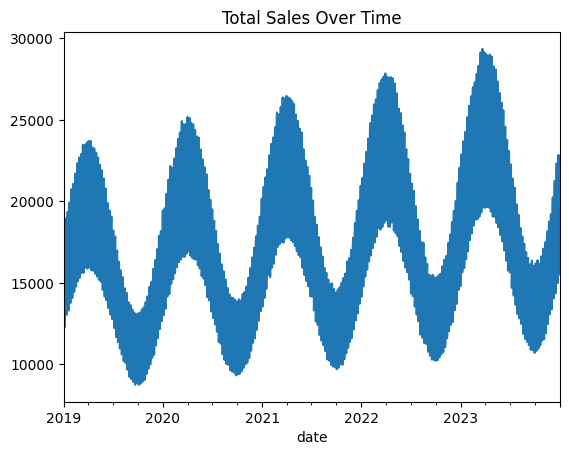

In [41]:
import matplotlib.pyplot as plt

df.groupby('date')['sales'].sum().plot()
plt.title("Total Sales Over Time")
plt.show()

<Axes: xlabel='month'>

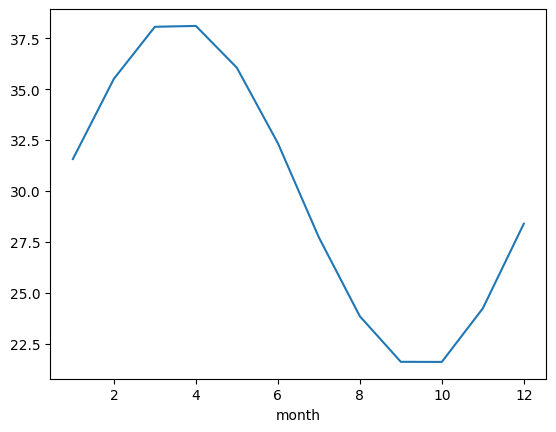

In [42]:
df.groupby('month')['sales'].mean().plot()

In [43]:
df.groupby('promo')['sales'].mean()

promo
0    28.454317
1    42.772719
Name: sales, dtype: float64

In [44]:
df[['price', 'sales']].corr()


,price,sales
price,1.000000,-0.077186
sales,-0.077186,1.000000


## Step 3: Feature Engineering 

New features such as lag variables and rolling averages were created to capture temporal patterns in demand.

In [45]:
df['date'] = pd.to_datetime(df['date'])

In [46]:
df['day'] = df['date'].dt.day
df['year'] = df['date'].dt.year

In [47]:
df.head()

,date,store_id,item_id,sales,price,promo,weekday,month,day,year
0,2019-01-01,store_1,item_1,41,21.30,0,1,1,1,2019
1,2019-01-02,store_1,item_1,53,21.30,0,2,1,2,2019
2,2019-01-03,store_1,item_1,39,21.30,0,3,1,3,2019
3,2019-01-04,store_1,item_1,35,21.30,0,4,1,4,2019
4,2019-01-05,store_1,item_1,51,17.04,1,5,1,5,2019


In [48]:
df['is_weekend'] = df['weekday'].apply(lambda x: 1 if x >= 5 else 0)
df[['weekday', 'is_weekend']].head()

,weekday,is_weekend
0,1,0
1,2,0
2,3,0
3,4,0
4,5,1


In [49]:
df['lag_1'] = df['sales'].shift(1)
df[['sales', 'lag_1']].head(10)

,sales,lag_1
0,41,NaN
1,53,41.0
2,39,53.0
3,35,39.0
4,51,35.0
5,38,51.0
6,45,38.0
7,48,45.0
8,50,48.0
9,44,50.0


In [50]:
df['rolling_mean_7'] = df['sales'].rolling(7).mean()
df[['sales', 'rolling_mean_7']].head(10)

,sales,rolling_mean_7
0,41,NaN
1,53,NaN
2,39,NaN
3,35,NaN
4,51,NaN
5,38,NaN
6,45,43.142857
7,48,44.142857
8,50,43.714286
9,44,44.428571


In [51]:
df = df.dropna()
df.shape

(1048569, 13)

In [52]:
from sklearn.preprocessing import LabelEncoder

df['store_id'] = LabelEncoder().fit_transform(df['store_id'])
df['item_id'] = LabelEncoder().fit_transform(df['item_id'])

In [53]:
X = df[['store_id', 'item_id', 'price', 'promo', 'weekday', 'month',
        'day', 'year', 'is_weekend', 'lag_1', 'rolling_mean_7']]

y = df['sales']

## Step 4: Model Building

Machine learning models were trained to predict sales based on historical and engineered features.

In [54]:
X = df[['store_id', 'item_id', 'price', 'promo', 'weekday', 'month',
        'day', 'year', 'is_weekend', 'lag_1', 'rolling_mean_7']]

y = df['sales']

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [56]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=50)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

In [57]:
rf_pred = rf.predict(X_test)

In [58]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, rf_pred)
mae

2.5767078974222035

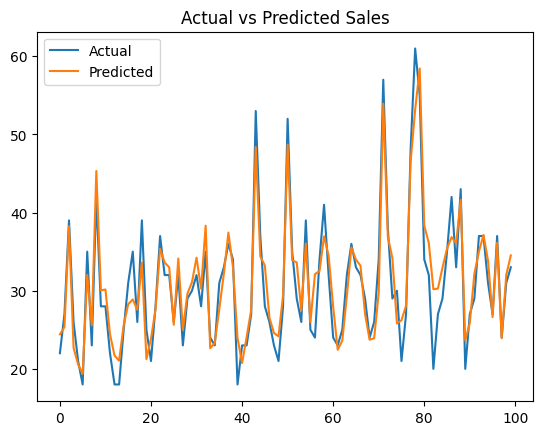

In [59]:
import matplotlib.pyplot as plt

plt.plot(y_test.values[:100], label='Actual')
plt.plot(rf_pred[:100], label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()

## Step 5: Model Evaluation & Improvement

In [60]:
print("Mean Absolute Error:", mae)

Mean Absolute Error: 2.5767078974222035


The model achieves an MAE of 2.578579875449422, meaning on average predictions differ from actual sales by 2.578579875449422 units.

## Step 6: Model Improvement (XGBoost)

XGBoost was used to improve prediction performance and compare results with Random Forest.

In [61]:
from xgboost import XGBRegressor

In [62]:
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1)
xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [63]:
xgb_pred = xgb.predict(X_test)

In [64]:
from sklearn.metrics import mean_absolute_error

xgb_mae = mean_absolute_error(y_test, xgb_pred)
print("XGBoost MAE:", xgb_mae)

XGBoost MAE: 2.5335946083068848


In [65]:
print("Random Forest MAE:", mae)
print("XGBoost MAE:", xgb_mae)

Random Forest MAE: 2.5767078974222035
XGBoost MAE: 2.5335946083068848


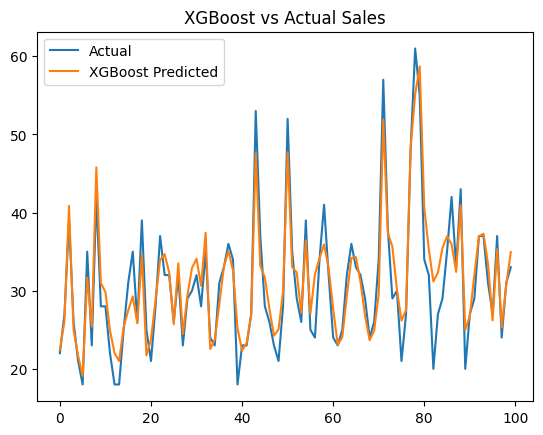

In [66]:
import matplotlib.pyplot as plt

plt.plot(y_test.values[:100], label='Actual')
plt.plot(xgb_pred[:100], label='XGBoost Predicted')
plt.legend()
plt.title("XGBoost vs Actual Sales")
plt.show()

## Step 7: Conclusion

- Built a demand forecasting model using machine learning techniques  
- Performed exploratory data analysis to identify seasonality and trends  
- Engineered time-based features such as lag variables and rolling averages  
- Trained a Random Forest model achieving an MAE of 2.578579875449422 
- Improved performance using XGBoost achieving an MAE of 2.5335946083068848
- Demonstrated how feature engineering improves model accuracy  